In [37]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [38]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df = df.drop("customerID", axis=1)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

In [39]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [40]:
y = df["Churn"]
X = df.drop("Churn", axis=1)

In [41]:
X = pd.get_dummies(X, drop_first=True)

Train Test Split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Scaling

In [43]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

MODEL 1 — KNN

In [44]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

MODEL 2 — Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

MODEL 3 — Decision Tree

In [46]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

MODEL 4 — Random Forest

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

EVALUATION (ALL MODELS)

In [48]:
def evaluate(name, y_test, y_pred):
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

In [49]:
evaluate("KNN", y_test, y_pred_knn)
evaluate("Logistic Regression", y_test, y_pred_lr)
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Random Forest", y_test, y_pred_rf)


 KNN
Accuracy: 0.7526652452025586
Precision: 0.536723163841808
Recall: 0.5080213903743316
F1 Score: 0.521978021978022

 Logistic Regression
Accuracy: 0.7874911158493249
Precision: 0.6205787781350482
Recall: 0.516042780748663
F1 Score: 0.5635036496350365

 Decision Tree
Accuracy: 0.7256574271499645
Precision: 0.4852216748768473
Recall: 0.5267379679144385
F1 Score: 0.5051282051282051

 Random Forest
Accuracy: 0.7846481876332623
Precision: 0.6254416961130742
Recall: 0.4732620320855615
F1 Score: 0.5388127853881278


CONFUSION MATRIX

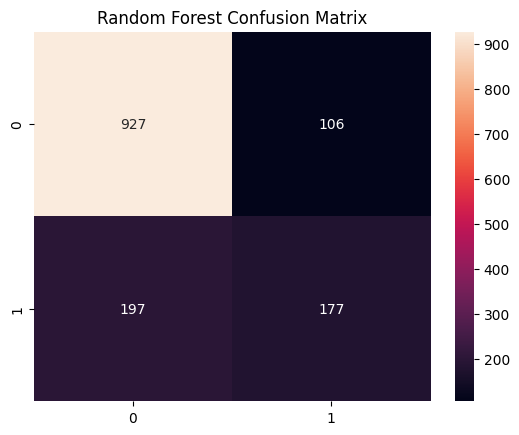

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

In [51]:
models = {
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf)
}

best_model = max(models, key=models.get)

print("Best Model:", best_model)
print(models)

Best Model: Logistic Regression
{'KNN': 0.7526652452025586, 'Logistic Regression': 0.7874911158493249, 'Decision Tree': 0.7256574271499645, 'Random Forest': 0.7846481876332623}


In [52]:
import joblib

joblib.dump(knn, "../models/knn_model.pkl")
joblib.dump(lr, "../models/logistic_model.pkl")
joblib.dump(dt, "../models/decision_tree.pkl")
joblib.dump(rf, "../models/random_forest.pkl")

['../models/random_forest.pkl']